In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F #moves data forward in function
import numpy as np


Using: cuda
Numpy version: 2.4.2


In [2]:
# Create Model Class that inherits nn.Module
class Model(nn.Module): #class = neural network, doing nn.Module means it is able to use all of these features
    #input layer with 4 features --> hidden layer 1 --> hidden layer 2 --> single output
    def __init__(self, in_features=4, h1=64, h2=32, out_features=1): #creates layers
        super().__init__() #sets up parent class initialisation of nn.Module
        self.fc1 = nn.Linear(in_features, h1) #creating hidden layer 1 here with in_features number of inputs and h1 number of outputs
        self.fc2 = nn.Linear(h1,h2) 
        self.out = nn.Linear(h2,out_features) #even for nonlinear datasets, nn.Linear is the choice here, just need to add activation later
    def forward(self,x): #function which moves data through network, x is the variable here which gets moved through
        x = F.relu(self.fc1(x)) #Activation ReLU function (Rectified Linear Unit)
        x = F.relu(self.fc2(x)) 
        x = self.out(x) #No activation function on final layer
        return x

In [3]:
torch.manual_seed(10)
model = Model() #create model

In [4]:
#import stoichiometric DNS data (20 points)
import pandas as pd
import os 

data_path_stoichiometric = r'C:\Users\Jamie Harvey\OneDrive - The University of Manchester\Desktop\data_out'
all_data_stoichiometric = []

for i in range(10000, 10020):
    # Read nodes
    nodes_df = pd.read_csv(os.path.join(data_path_stoichiometric, f'nodes_{i}'),
                          sep=r'\s+', skiprows=1,
                          names=['dummy1', 'x', 'y', 'dx', 'dummy2', 'dummy3', 'dummy4']) #path join searches for file name in folder, skip header rows
    
    # Read fields  
    fields_df = pd.read_csv(os.path.join(data_path_stoichiometric, f'fields_{i}_2'),
                           sep=r'\s+', skiprows=5, header=None, names=['density', 'u', 'v', 'vorticity', 'temperature', 
              'pressure', 'HRR', 'ms1', 'ms2', 'ms3', 'ms4', 
              'ms5', 'ms6', 'ms7', 'ms8', 'ms9']) #/s+ seperation is for constant seperation which is more than one space
    
    # Combine nodes + fields
    combined = pd.concat([nodes_df, fields_df], axis=1) #horizontal merge of data, axis=1 specifies horizontal
    combined['processor'] = i
    combined['phi']=1
    all_data_stoichiometric.append(combined) #adds this combined processor data to the list of dataframes all_data

df_stoichiometric = pd.concat(all_data_stoichiometric, ignore_index=True) #combines into a single dataframe and removes indexing of each

ms1_unburned = df_stoichiometric['ms1'].max()
df_stoichiometric['c'] = (1 - (df_stoichiometric['ms1'] / ms1_unburned)).clip(0, 1)

df_stoichiometric

,dummy1,x,y,dx,dummy2,dummy3,dummy4,density,u,v,...,ms3,ms4,ms5,ms6,ms7,ms8,ms9,processor,phi,c
0,26,-0.500,-0.004,0.003,0.0072,0.0072,1,0.843706,2.049993,9.462150e-12,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.745187,10000,1,1.122107e-09
1,27,-0.497,-0.004,0.003,0.0072,0.0072,-1,0.843706,2.049993,4.656218e-11,...,7.841136e-31,-1.028150e-33,-7.394585e-31,-6.100516e-29,2.014742e-27,2.770231e-32,0.745187,10000,1,1.122127e-09
2,28,-0.494,-0.004,0.003,0.0072,0.0072,-2,0.843706,2.049993,5.883364e-11,...,1.568227e-30,-2.056222e-33,-1.478917e-30,-1.220104e-28,4.029371e-27,3.146110e-32,0.745187,10000,1,1.122150e-09
3,29,-0.491,-0.004,0.003,0.0072,0.0072,-3,0.843706,2.049993,5.616350e-11,...,2.352341e-30,-3.084249e-33,-2.218376e-30,-1.830157e-28,6.043934e-27,1.978784e-32,0.745187,10000,1,1.122177e-09
4,30,-0.488,-0.004,0.003,0.0072,0.0072,-4,0.843706,2.049993,4.347806e-11,...,3.136455e-30,-4.112264e-33,-2.957835e-30,-2.440210e-28,8.058480e-27,1.729953e-33,0.745187,10000,1,1.122206e-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7974,7950,0.500,0.010,0.003,0.0072,0.0072,2,0.123942,14.228926,8.971130e-04,...,2.367017e-01,6.395209e-04,6.334371e-03,1.213254e-04,2.203018e-06,3.342610e-07,0.745151,10019,1,9.469312e-01
7975,7951,0.497,0.010,0.003,0.0072,0.0072,-1,0.123961,14.226784,9.011313e-04,...,2.366621e-01,6.423568e-04,6.345731e-03,1.218893e-04,2.206033e-06,3.360365e-07,0.745151,10019,1,9.468195e-01
7976,7952,0.494,0.010,0.003,0.0072,0.0072,-2,0.123980,14.224625,9.051094e-04,...,2.366225e-01,6.452033e-04,6.357091e-03,1.224551e-04,2.209065e-06,3.378227e-07,0.745151,10019,1,9.467077e-01
7977,7953,0.491,0.010,0.003,0.0072,0.0072,-3,0.123999,14.222444,9.090438e-04,...,2.365827e-01,6.480655e-04,6.368471e-03,1.230237e-04,2.212120e-06,3.396229e-07,0.745151,10019,1,9.465957e-01


In [5]:
#import other equivalence ratio data (only 10 data points)
phis = [0.4,0.5,0.6,0.7,0.8]
all_data_phis = []

base_path_phis = r'C:\Users\Jamie Harvey\OneDrive - The University of Manchester\Desktop\y3 individual project\Sample Data 1D - Different phi'

for phi in phis:
    data_phi=[]
    for i in range(10000, 10010):
    # Read nodes
        nodes_df = pd.read_csv(os.path.join(base_path_phis, f'data_phi{phi}', 'data_out', f'nodes_{i}'),
                          sep=r'\s+', skiprows=1,
                          names=['dummy1', 'x', 'y', 'dx', 'dummy2', 'dummy3', 'dummy4']) #path join searches for file name in folder, skip header rows
    
    # Read fields  
        fields_df = pd.read_csv(os.path.join(base_path_phis, f'data_phi{phi}', 'data_out', f'fields_{i}_2'),
                           sep=r'\s+', skiprows=5, header=None, names=['density', 'u', 'v', 'vorticity', 'temperature', 
              'pressure', 'HRR', 'ms1', 'ms2', 'ms3', 'ms4', 
              'ms5', 'ms6', 'ms7', 'ms8', 'ms9']) #/s+ seperation is for constant seperation which is more than one space
    
    # Combine nodes + fields
        combined = pd.concat([nodes_df, fields_df], axis=1) #horizontal merge of data, axis=1 specifies horizontal
        combined['processor'] = i
        data_phi.append(combined) #adds this combined processor data to the list of dataframes all_data

    df_data_phi = pd.concat(data_phi, ignore_index=True)
    df_data_phi['phi']=phi

    ms1_unburned = df_data_phi['ms1'].max()  # Y_H2 in unburned reactants
    df_data_phi['c'] = (1 - (df_data_phi['ms1'] / ms1_unburned)).clip(0, 1)

    all_data_phis.append(df_data_phi)

df_phis = pd.concat(all_data_phis, ignore_index=True) #combines into a single dataframe and removes indexing of each
print(df_phis)

       dummy1    x      y      dx  dummy2  dummy3  dummy4   density         u  \
0    -0.00500  0.0  0.001  0.0024       1     NaN     NaN  1.008149  0.250000   
1    -0.00499  0.0  0.001  0.0024      -1     NaN     NaN  1.008149  0.250000   
2    -0.00498  0.0  0.001  0.0024      -2     NaN     NaN  1.008149  0.250000   
3    -0.00497  0.0  0.001  0.0024      -3     NaN     NaN  1.008149  0.250000   
4    -0.00496  0.0  0.001  0.0024      -4     NaN     NaN  1.008149  0.250000   
...       ...  ...    ...     ...     ...     ...     ...       ...       ...   
5000  0.00500  0.0  0.001  0.0024       2     NaN     NaN  0.148522  5.310863   
5001  0.00499  0.0  0.001  0.0024      -1     NaN     NaN  0.148529  5.310438   
5002  0.00498  0.0  0.001  0.0024      -2     NaN     NaN  0.148537  5.310013   
5003  0.00497  0.0  0.001  0.0024      -3     NaN     NaN  0.148545  5.309587   
5004  0.00496  0.0  0.001  0.0024      -4     NaN     NaN  0.148552  5.309160   

        v  ...           ms

In [6]:
# Combine DataFrames
df = pd.concat([df_stoichiometric, df_phis], ignore_index=True)
print(df)

         dummy1      x      y      dx  dummy2  dummy3  dummy4   density  \
0      26.00000 -0.500 -0.004  0.0030  0.0072  0.0072     1.0  0.843706   
1      27.00000 -0.497 -0.004  0.0030  0.0072  0.0072    -1.0  0.843706   
2      28.00000 -0.494 -0.004  0.0030  0.0072  0.0072    -2.0  0.843706   
3      29.00000 -0.491 -0.004  0.0030  0.0072  0.0072    -3.0  0.843706   
4      30.00000 -0.488 -0.004  0.0030  0.0072  0.0072    -4.0  0.843706   
...         ...    ...    ...     ...     ...     ...     ...       ...   
12979   0.00500  0.000  0.001  0.0024  2.0000     NaN     NaN  0.148522   
12980   0.00499  0.000  0.001  0.0024 -1.0000     NaN     NaN  0.148529   
12981   0.00498  0.000  0.001  0.0024 -2.0000     NaN     NaN  0.148537   
12982   0.00497  0.000  0.001  0.0024 -3.0000     NaN     NaN  0.148545   
12983   0.00496  0.000  0.001  0.0024 -4.0000     NaN     NaN  0.148552   

              u             v  ...           ms3           ms4           ms5  \
0      2.049993  9.

In [7]:
#Reducing DF to region of significant chemistry
df_filtered = df[df['c'].between(0.1, 0.9)]
df_filtered

,dummy1,x,y,dx,dummy2,dummy3,dummy4,density,u,v,...,ms3,ms4,ms5,ms6,ms7,ms8,ms9,processor,phi,c
3121,3116.00000,-0.035308,-0.001345,0.0010,0.002700,0.002700,999.0,0.723857,2.397403,0.001060,...,0.005771,0.000003,0.000033,0.000001,0.000342,0.000074,0.743555,10007,1.0,0.100386
3122,3123.00000,-0.035260,0.007355,0.0010,0.002700,0.002700,999.0,0.721872,2.404556,-0.001784,...,0.005873,0.000003,0.000035,0.000001,0.000348,0.000075,0.743517,10007,1.0,0.101366
3123,3124.00000,-0.035240,0.005412,0.0010,0.002700,0.002700,999.0,0.720819,2.407623,-0.001226,...,0.005922,0.000003,0.000036,0.000001,0.000350,0.000076,0.743499,10007,1.0,0.101774
3124,3125.00000,-0.035233,-0.012174,0.0010,0.002646,0.002646,999.0,0.720612,2.406169,0.001152,...,0.005938,0.000003,0.000036,0.000001,0.000353,0.000076,0.743492,10007,1.0,0.101972
3125,3126.00000,-0.035177,-0.009283,0.0010,0.002541,0.002541,999.0,0.717855,2.415181,0.002437,...,0.006070,0.000003,0.000038,0.000001,0.000358,0.000078,0.743447,10007,1.0,0.103087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12532,0.00049,0.000000,0.001000,0.0027,999.000000,NaN,NaN,0.186902,4.171923,0.000000,...,0.165695,0.006014,0.006537,0.001041,0.000027,0.000012,0.746700,10005,0.8,0.892767
12533,0.00050,0.000000,0.001000,0.0027,999.000000,NaN,NaN,0.186157,4.188002,0.000000,...,0.166312,0.006026,0.006627,0.001034,0.000027,0.000012,0.746811,10005,0.8,0.894650
12534,0.00051,0.000000,0.001000,0.0027,999.000000,NaN,NaN,0.185438,4.203669,0.000000,...,0.166899,0.006035,0.006715,0.001027,0.000026,0.000012,0.746915,10005,0.8,0.896412
12535,0.00052,0.000000,0.001000,0.0027,999.000000,NaN,NaN,0.184742,4.218939,0.000000,...,0.167456,0.006041,0.006799,0.001020,0.000026,0.000012,0.747013,10005,0.8,0.898062


In [8]:
# How many points excluded by c filtering
total_points = len(df)
filtered_points = len(df_filtered)
excluded_points = total_points - filtered_points

Total points before filtering: 12984
Points retained (0.1 < c < 0.9): 2831
Points excluded: 10153 (78.2%)

=== FILTERING BREAKDOWN BY PHI ===
  phi=0.4: 1001 → 111 retained (11.1%)
  phi=0.5: 1001 → 88 retained (8.8%)
  phi=0.6: 1001 → 79 retained (7.9%)
  phi=0.7: 1001 → 76 retained (7.6%)
  phi=0.8: 1001 → 81 retained (8.1%)
  phi=1.0: 7979 → 2396 retained (30.0%)


In [9]:
#step 2 - specifying variables of interest
#For this basic model, 4 inputs, 1 output
model_variables = ['density','phi','temperature','c','HRR']
model_data = df_filtered[model_variables]

print(model_data)

X=model_data[['density','phi','temperature','c']].values
y=model_data['HRR'].values

        density  phi  temperature         c           HRR
3121   0.723857  1.0   356.254976  0.100386  6.159117e+08
3122   0.721872  1.0   357.315389  0.101366  6.493856e+08
3123   0.720819  1.0   357.870300  0.101774  6.638371e+08
3124   0.720612  1.0   357.990286  0.101972  6.712471e+08
3125   0.717855  1.0   359.455320  0.103087  7.128608e+08
...         ...  ...          ...       ...           ...
12532  0.186902  0.8  1564.540418  0.892767  9.273180e+08
12533  0.186157  0.8  1571.112576  0.894650  9.042734e+08
12534  0.185438  0.8  1577.524643  0.896412  8.819433e+08
12535  0.184742  0.8  1583.782230  0.898062  8.603155e+08
12536  0.184068  0.8  1589.890749  0.899606  8.393759e+08

[2831 rows x 5 columns]


In [10]:
from sklearn.model_selection import train_test_split
phi_col=1 #define what column phi is located it to ensure proper stratification
X_train_unscaled, X_unseen_unscaled, y_train_unscaled, y_unseen_unscaled = train_test_split(X,y,test_size=0.2,random_state=12,stratify=model_data['phi']) #must s
X_test_unscaled, X_val_unscaled, y_test_unscaled, y_val_unscaled = train_test_split(X_unseen_unscaled,y_unseen_unscaled,test_size=0.5,random_state=12,stratify=X_unseen_unscaled[:, phi_col])#stratify ensures proportional split of phi values 

#scale data
from sklearn.preprocessing import StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train_unscaled) #apply normalisation
X_val = scaler_X.transform(X_val_unscaled)   
X_test = scaler_X.transform(X_test_unscaled)        

y_train_log = np.log1p(y_train_unscaled)  
y_val_log = np.log1p(y_val_unscaled)  
y_test_log = np.log1p(y_test_unscaled)    
y_train = scaler_y.fit_transform(y_train_log.reshape(-1, 1))
y_val = scaler_y.transform(y_val_log.reshape(-1, 1))
y_test = scaler_y.transform(y_test_log.reshape(-1, 1))   

#convert numpy arrays into tensors for use in PyTorch
X_train = torch.FloatTensor(X_train) #for floats
X_val = torch.FloatTensor(X_val)
X_test = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train).view(-1,1) #reshape
y_val = torch.FloatTensor(y_val).view(-1,1) 
y_test = torch.FloatTensor(y_test).view(-1,1) 

In [12]:
criterion = nn.MSELoss() #Mean Squared Error for regression
optimiser = torch.optim.Adam(model.parameters(),lr=0.001) #choose optimiser and learning rate, model parameters are the layers

In [13]:
best_val_loss = float('inf')
min_improvement = 0.02
patience = 30
patience_counter = 0

In [14]:
from codecarbon import EmissionsTracker #carbon emission tracker
import time

tracker = EmissionsTracker()
tracker.start()
start_training=time.time()

[codecarbon WARNING @ 18:01:58] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 18:01:59] [setup] RAM Tracking...
[codecarbon INFO @ 18:01:59] [setup] CPU Tracking...
[codecarbon WARNING @ 18:02:00] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 18:02:00] CPU Model on constant consumption mode: 12th Gen Intel(R) Core(TM) i7-12700H
[codecarbon WARNING @ 18:02:00] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 18:02:00] [setup] GPU Tracking...
[codecarbon INFO @ 18:02:00] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @ 18:02:00] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: cpu_load
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 18:02:00] >>> Tracker's metadata:
[code

In [15]:
epochs=100000
train_losses=[] #list which will be added to
val_losses=[]
for i in range(epochs):
    model.train() #training mode
    #go forward and predict
    y_pred=model.forward(X_train) #get predicted results
    #Measure loss
    train_loss = criterion(y_pred,y_train)
    train_losses.append(train_loss.detach().numpy()) #convert loss back from tensor to numpy

    #Back propagation (fine tuning of neuron parameters)
    optimiser.zero_grad() #resets gradient calculation (neccesary)
    train_loss.backward() #works out gradient for each weight (how much each weight contributed to error)
    optimiser.step() #gradient descent to update weight based on optimiser (optimiser determines how much to change weight by)

    #validation
    model.eval()  # evaluation mode
    with torch.no_grad():  # No gradient computation for validation
        y_val_pred = model.forward(X_val)
        val_loss = criterion(y_val_pred, y_val)
        val_losses.append(val_loss.detach().numpy())

    # Early stopping check
    if val_loss < best_val_loss * (1 - min_improvement):
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pt')
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print(f"Early stopping at epoch {i}, best val loss: {best_val_loss:.5f}")
        break
        
    #print every 50 epochs
    if i % 500 == 0: #% operator gives remainder 
        print(f'Epoch:{i}, Training loss: {train_loss}, Validation Loss: {val_loss}')

model.load_state_dict(torch.load('best_model.pt',weights_only=True))
print("Best model loaded")

Epoch:0, Training loss: 1.084771752357483, Validation Loss: 0.8763567209243774
Epoch:500, Training loss: 0.003515827702358365, Validation Loss: 0.002756828675046563
Epoch:1000, Training loss: 0.0008801131043583155, Validation Loss: 0.0008758856565691531
Epoch:1500, Training loss: 0.0005381524097174406, Validation Loss: 0.0005273746210150421
Early stopping at epoch 1604, best val loss: 0.00049
Best model loaded


In [16]:
training_time=time.time()-start_training
print(f"Training time: {training_time} secs")

training_emissions=tracker.stop()
print(f"Training Emissions: {training_emissions} kg CO2")

[codecarbon INFO @ 18:02:12] Energy consumed for RAM : 0.000043 kWh. RAM Power : 20.0 W


Training time: 6.634553670883179 secs


[codecarbon INFO @ 18:02:12] Delta energy consumed for CPU with cpu_load : 0.000017 kWh, power : 8.16284139557143 W
[codecarbon INFO @ 18:02:12] Energy consumed for All CPU : 0.000017 kWh
[codecarbon INFO @ 18:02:12] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 18:02:12] Energy consumed for all GPUs : 0.000068 kWh. Total GPU Power : 29.874282728592412 W
[codecarbon INFO @ 18:02:12] 0.000128 kWh of electricity and 0.000000 L of water were used since the beginning.


Training Emissions: 3.0301417890677906e-05 kg CO2


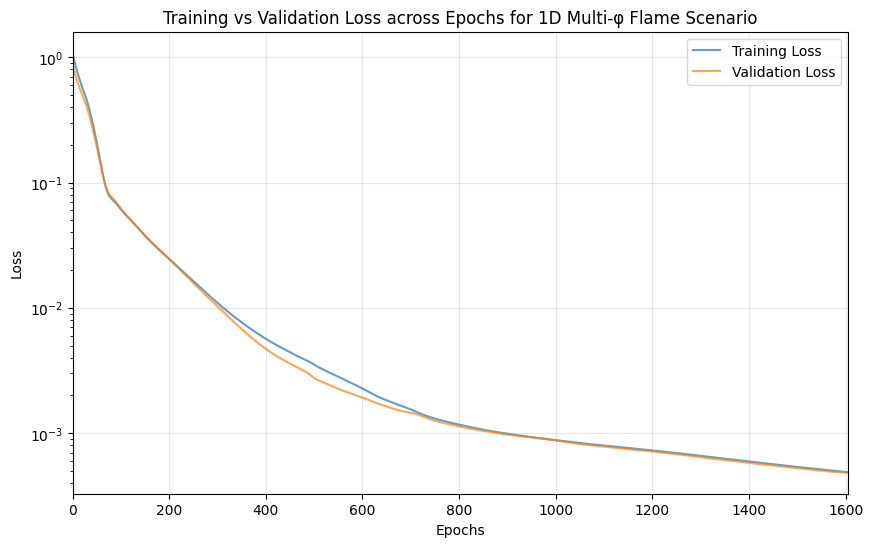

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', alpha=0.7)
plt.plot(val_losses, label='Validation Loss', alpha=0.7)
plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xlim(0,i)
plt.title('Training vs Validation Loss across Epochs for 1D Multi-φ Flame Scenario')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
tracker.start()
start_inference=time.time()

[codecarbon WARNING @ 18:02:13] Already started tracking


In [19]:
#Evaluate Model
with torch.no_grad():
    y_pred_scaled = model(X_test)
    
    y_pred_log = scaler_y.inverse_transform(y_pred_scaled.numpy().reshape(-1, 1))
    y_test_log = scaler_y.inverse_transform(y_test.numpy().reshape(-1, 1))

    y_pred_actual = np.expm1(y_pred_log)  
    y_test_actual = np.expm1(y_test_log) 

In [20]:
inference_time=time.time()-start_inference
print(f"Inference time: {inference_time} secs, Inference time per sample: {inference_time/len(X_test)*1000:.4f}ms")

[codecarbon WARNING @ 18:02:13] Tracker already stopped !
[codecarbon INFO @ 18:02:13] Energy consumed for RAM : 0.000050 kWh. RAM Power : 20.0 W


Inference time: 0.02138376235961914 secs, Inference time per sample: 0.0756ms


[codecarbon INFO @ 18:02:14] Delta energy consumed for CPU with cpu_load : 0.000002 kWh, power : 4.875070500000002 W
[codecarbon INFO @ 18:02:14] Energy consumed for All CPU : 0.000019 kWh
[codecarbon INFO @ 18:02:14] Energy consumed for all GPUs : 0.000078 kWh. Total GPU Power : 19.314951539229096 W
[codecarbon INFO @ 18:02:14] 0.000147 kWh of electricity and 0.000000 L of water were used since the beginning.


Training Emissions: 3.482554512445708e-05 kg CO2


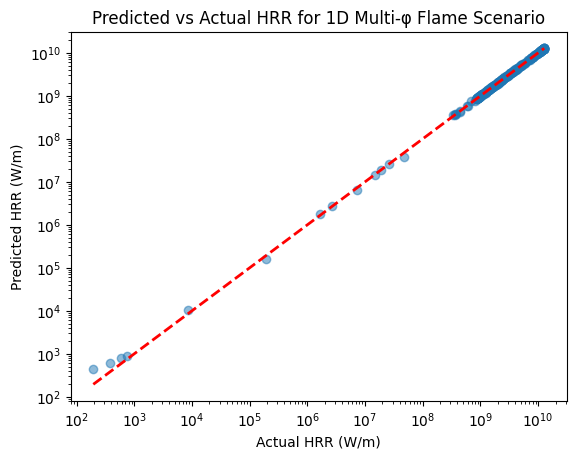

In [29]:
y_pred_np = y_pred_actual.flatten()
y_test_np = y_test_actual.flatten()

plt.scatter(y_test_np,y_pred_np,alpha=0.5)
plt.xlabel('Actual HRR (W/m)')
plt.ylabel('Predicted HRR (W/m)')
plt.yscale('log')
plt.xscale('log')
plt.title('Predicted vs Actual HRR for 1D Multi-φ Flame Scenario')
plt.plot([y_test_np.min(), y_test_np.max()],   # x-coordinates (start, end)
         [y_test_np.min(), y_test_np.max()],   # y-coordinates (start, end)
         'r--', lw=2)
plt.show()

In [22]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

r2 = r2_score(y_test_np, y_pred_np)
mae = mean_absolute_error(y_test_np, y_pred_np)
rmse = np.sqrt(mean_squared_error(y_test_np, y_pred_np))
mape = mean_absolute_percentage_error(y_test_actual, y_pred_actual) * 100
nmse = mean_squared_error(y_test_np, y_pred_np)/np.var(y_test_np)

#new metric - normalised MSE


print(f"\nR² Score: {r2:.4f}")
print(f"MAE:      {mae:.2f}")
print(f"RMSE:     {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")  
print(f"NMSE: {nmse:.5f}") 


R² Score: 0.9999
MAE:      16110673.00
RMSE:     30949952.77
MAPE: 1.72%
NMSE: 0.00006


In [23]:
print(f"Predicted HRR range: {y_pred_np.min():.4f} to {y_pred_np.max():.4f}")
print(f"Actual HRR range:    {y_test_np.min():.4f} to {y_test_np.max():.4f}")

Predicted HRR range: 441.8766 to 12683465728.0000
Actual HRR range:    194.6015 to 12737334272.0000
